## Processing, vizualization, and statistical analysis of metatranscriptome data

In [3]:
import pandas as pd
#pip install -U numpy==1.26.4
import numpy as np
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import matplotlib
import pypalettes
from pypalettes import load_cmap
from pypalettes import get_hex
from matplotlib.patches import Patch
from Bio import SeqIO
from scipy import stats
from scipy.stats import zscore
from scipy.stats import tukey_hsd
from matplotlib.patches import Patch
from matplotlib.patches import Circle
import matplotlib.lines as mlines
from ete3 import NCBITaxa

In [61]:
#Load info to convert ncbi accessions to taxonomy
#ncbi = NCBITaxa()

In [4]:
#Standardize figure aesthetics and save dictionary of sample types
sns.set_theme(context = 'paper',style='white',font_scale=2)
sample_dict = {'SS0122_S12':'Dilute','SS0123_S13':'Dilute','SS0125_S15':'Dilute','SS0126_S16':'Dilute',
               'SS0124_S14':'Concentrated','SS0127_S17':'Concentrated'}

## Differential expression of phage genes on picked colonies (dilute Tricho population) vs. in slick (concentrated Tricho population)

In [69]:
##Read in BWA mapping to virus genome
slick_annotations = pd.read_csv('annotation_files/unified_annotations_slick.csv').dropna(how='all',axis=1)
slick_bed = slick_annotations[['cds_id','start','end']]
slick_bed.loc[:,'start'] = slick_annotations[['start','end']].min(axis=1)
slick_bed.loc[:,'end'] = slick_annotations[['start','end']].max(axis=1)
to_cat = []
#For each sample, read in coverage file resulting from BWA mapping to T.NPSG.2 genome (slick phage)
for file in glob.glob('metaT_files/*_phage_metaT_coverage.tab'):
    temp_bed = slick_bed.copy()
    sample_id = file.rsplit('/',maxsplit=1)[1].split('_')[0]+'_'+file.rsplit('/',maxsplit=1)[1].split('_')[1]
    #read in bwa mapping to metatranscriptome assembly to calculate sum of all RPKs
    all_cov = pd.read_csv('metaT_files/'+sample_id+'_L006_metaT_coverage.tab',sep='\t')
    pm_scale = (all_cov['numreads']/(all_cov['endpos']/1000)).sum()/1000000
    #read in bwa mapping to phage genome
    infile = pd.read_csv(file,sep='\t',header=None,names=['genome','start','end','depth','reads']).drop(['genome'],axis=1).set_index('end')
    temp_bed.loc[:,'depth'] = temp_bed['end'].map(infile['depth'])
    temp_bed.loc[:,'reads'] = temp_bed['end'].map(infile['reads'])
    temp_bed.loc[:,'length'] = temp_bed['end'] - temp_bed['start']
    #rpk = reads mapped per kilobase of CDS, add .5 to all so no zeros in final dataset
    temp_bed.loc[:,'rpk'] = (temp_bed['reads'])/(temp_bed['length']/1000)
    temp_bed.loc[:,'tpm'] = (temp_bed['rpk']/pm_scale)
    temp_bed = temp_bed.set_index('cds_id')
    tpms = temp_bed['tpm']
    tpms.name = sample_id
    to_cat.append(tpms)

phage_tpm = pd.concat(to_cat,axis=1)
#phage_tpm.to_csv('metaT_files/phage_tpm.csv')

In [5]:
phage_tpm = pd.read_csv('metaT_files/phage_tpm.csv',index_col=0)

In [71]:
#Set color palette for phage gene TPM by functional group - same as Figure 1a
hex_colors = load_cmap("golduck").hex
function_palette = {'tail':hex_colors[5], 'head and packaging':hex_colors[8],
                    'DNA, RNA and nucleotide metabolism':hex_colors[0],'integration and excision':hex_colors[1],'transcription regulation':hex_colors[2],'RM system':hex_colors[3], 'Phage defense':'#d0eafb',
                   'auxiliary metabolism, host takeover':hex_colors[9],'Host range determination':hex_colors[12],'lysis':hex_colors[11],
                    'unknown function':'#cccccc', 'conserved protein of unknown function':'#000000'}

In [72]:
slick_annotations = slick_annotations.set_index('cds_id')
slick_annotations.loc[:,'color'] = slick_annotations['function'].map(function_palette)
tpm_stacked = phage_tpm.stack().reset_index()
tpm_stacked.columns = ['cds_id','sample','tpm']
tpm_stacked.loc[:,'log_tpm'] = np.log10(tpm_stacked['tpm'])
tpm_stacked.loc[:,'source'] = tpm_stacked['sample'].map(sample_dict)
tpm_stacked.loc[:,'function'] = tpm_stacked['cds_id'].map(slick_annotations['function'])

/jet/home/agomez3/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/var/tmp/ipykernel_48940/3720796206.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Dilute\n colonies','Concentrated\n slick'],fontsize=16)
/jet/home/agomez3/.local/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/jet/home/agomez3/.local/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/jet/home/agomez3/.local/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/jet/home/agomez3/.local/lib/python3.12/site-pack

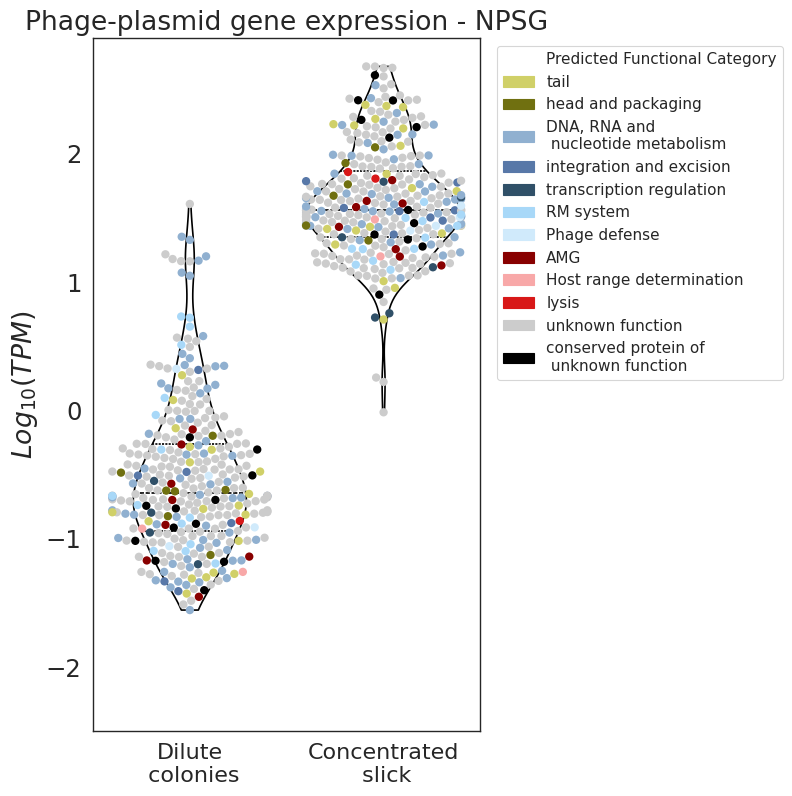

In [73]:
fig, ax = plt.subplots(figsize=(5,9))
g = sns.swarmplot(data=tpm_stacked,x='source',y='log_tpm',hue='function',palette=function_palette,ax=ax,legend=False,s=6)
j = sns.violinplot(data=tpm_stacked,x='source',y='log_tpm',ax=ax,cut=0,fill=False,inner="quart",color='black')
handles1 = []
handles1.append(Patch(color='#FFFFFF00',label='Predicted Functional Category'))
for i in function_palette.keys():
    if i == 'conserved protein of unknown function':
        handles1.append(Patch(color=function_palette[i],label='conserved protein of \n unknown function'))
    elif i == 'DNA, RNA and nucleotide metabolism':
        handles1.append(Patch(color=function_palette[i],label='DNA, RNA and \n nucleotide metabolism'))
    elif i == 'auxiliary metabolism, host takeover':
        handles1.append(Patch(color=function_palette[i],label='AMG'))
    else:
        handles1.append(Patch(color=function_palette[i],label=i))
first_legend = ax.legend(handles=handles1, bbox_to_anchor=(1.8,1), loc="upper right",fontsize=11)
ax.set_ylim(-2.5,2.9)
g.set_ylabel('$Log_{10}(TPM)$')
g.set_xlabel('')
g.set_xticklabels(['Dilute\n colonies','Concentrated\n slick'],fontsize=16)
g.set_title('Phage-plasmid gene expression - NPSG')
plt.savefig('output_figures/fig2a_phage_metaT_swarm.svg',transparent=True,bbox_inches='tight')

In [213]:
tpm_stacked[(tpm_stacked['source'] == 'Dilute')].sort_values(by='tpm')

,cds_id,sample,tpm,log_tpm,source,function
0,SHDOJQCQ_CDS_0001,SS0122_S12,0.000000,-inf,Dilute,unknown function
540,SHDOJQCQ_CDS_0091,SS0122_S12,0.000000,-inf,Dilute,tail
536,SHDOJQCQ_CDS_0090,SS0123_S13,0.000000,-inf,Dilute,conserved protein of unknown function
531,SHDOJQCQ_CDS_0089,SS0125_S15,0.000000,-inf,Dilute,unknown function
530,SHDOJQCQ_CDS_0089,SS0123_S13,0.000000,-inf,Dilute,unknown function
...,...,...,...,...,...,...
440,SHDOJQCQ_CDS_0074,SS0123_S13,15.878499,1.200809,Dilute,"DNA, RNA and nucleotide metabolism"
290,SHDOJQCQ_CDS_0049,SS0123_S13,16.470379,1.216704,Dilute,unknown function
878,SHDOJQCQ_CDS_0150,SS0123_S13,21.340540,1.329205,Dilute,"DNA, RNA and nucleotide metabolism"
438,SHDOJQCQ_CDS_0074,SS0122_S12,22.556565,1.353273,Dilute,"DNA, RNA and nucleotide metabolism"


In [9]:
tpm_stacked[(tpm_stacked['source'] == 'Dilute') & (tpm_stacked['log_tpm'] > 0.35)].sort_values(by='log_tpm')

,cds_id,sample,tpm,log_tpm,source,function
674,SHDOJQCQ_CDS_0114,SS0123_S13,2.257908,0.353706,Dilute,"DNA, RNA and nucleotide metabolism"
246,SHDOJQCQ_CDS_0042,SS0122_S12,2.273146,0.356627,Dilute,unknown function
666,SHDOJQCQ_CDS_0113,SS0122_S12,2.552123,0.406902,Dilute,"DNA, RNA and nucleotide metabolism"
277,SHDOJQCQ_CDS_0047,SS0126_S16,2.759295,0.440798,Dilute,"DNA, RNA and nucleotide metabolism"
780,SHDOJQCQ_CDS_0133,SS0122_S12,3.126755,0.495094,Dilute,unknown function
918,SHDOJQCQ_CDS_0158,SS0122_S12,3.243796,0.511054,Dilute,RM system
498,SHDOJQCQ_CDS_0084,SS0122_S12,3.461178,0.539224,Dilute,unknown function
786,SHDOJQCQ_CDS_0134,SS0122_S12,3.622827,0.559048,Dilute,unknown function
211,SHDOJQCQ_CDS_0036,SS0126_S16,3.692034,0.567266,Dilute,unknown function
877,SHDOJQCQ_CDS_0150,SS0126_S16,3.796094,0.579337,Dilute,"DNA, RNA and nucleotide metabolism"


In [10]:
#Kolmogorov-Smirnov test phage gene expression on picked colones vs. slick
non_slick = tpm_stacked[tpm_stacked['source'] == 'Dilute']['tpm']
slick = tpm_stacked[tpm_stacked['source'] == 'Concentrated']['tpm']
stats.kstest(slick, non_slick)

KstestResult(statistic=0.970679012345679, pvalue=4.997378844259627e-236, statistic_location=4.4957779473998745, statistic_sign=-1)

In [11]:
#Kolmogorov-Smirnov test phage structural gene expression on picked colones vs. slick
structural_tpm = tpm_stacked[(tpm_stacked['function'] == 'tail') | (tpm_stacked['function'] == 'head and packaging')]
non_slick = structural_tpm[structural_tpm['source'] == 'Dilute']['tpm']
slick = structural_tpm[structural_tpm['source'] == 'Concentrated']['tpm']
stats.kstest(slick, non_slick)

KstestResult(statistic=1.0, pvalue=5.744956841781287e-21, statistic_location=1.8816997248320806, statistic_sign=-1)

In [12]:
#phage_tpm.to_csv('output_tables/ST7_phage_tpm.csv')

## Bacterial community transcriptional activity on colonies vs slick

In [15]:
#Read in transcripts per million from salmon quantification of assembled transcripts
all_tpm = pd.read_csv('metaT_files/all_tpm.csv',index_col=0)
contig_tpms = all_tpm.groupby('contig').sum()
#Read in taxonomy estimations from GTDB
gtdb_tax = pd.read_csv('metaT_files/gtdb_taxonomy_result.tsv',sep='\t',header=None,names=['contig','taxid','rank','LCA','1','2','3','4']).drop(['1','2','3','4'],axis=1)
gtdb_tax.loc[:,'length'] = gtdb_tax['contig'].str.split('_',expand=True)[3].astype(int)

In [16]:
#Define function to get lineage names from GTDB last common ancestor (LCA) output
def get_lineage_names(LCA):
    taxid = ncbi.get_name_translator([LCA.strip()])[LCA.strip()][0]
    lineage = ncbi.get_lineage(taxid)
    ranks = ncbi.get_rank(lineage)
    names = ncbi.get_taxid_translator(lineage)
    inverted_dict = {value: names[key] for key, value in ranks.items()}
    all_ranks = ['domain','kingdom','phylum','class','order','family','genus','species']
    i = 0
    previous_rank = 'domain'
    new_dict = {}
    unclassified = False
    while i < 8:
        rank = all_ranks[i]
        if unclassified:
            new_dict[rank] = propogate
        elif rank in inverted_dict.keys():
            new_dict[rank] = inverted_dict[rank]
        else:
            new_dict[rank] = 'unclassified '+ inverted_dict[all_ranks[i-1]]
            propogate = 'unclassified '+ inverted_dict[all_ranks[i-1]]
            unclassified = True
        i += 1
    taxid_series = pd.Series(new_dict)
    return(taxid_series)

In [17]:
#Fix outdated names
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp023356605','Trichodesmium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp023356535','Trichodesmium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp023356515','Trichodesmium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAKVCT01 sp022448995','Saprospiraceae bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Epibacterium sp004566265','Paracoccaceae bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JALEHC01 sp022448955','Saprospiraceae bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2683315 sp036127535','Deltaproteobacteria bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Alteromonas sp963922845','Alteromonas')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp010672385','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp010692555','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('CACIJG01','uncultured Alphaproteobacteria bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JANQNR01 sp028279475','Rickettsiales bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp002260545','Hydrocoleum sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA8653 sp002862275','Phycisphaerales bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JASJEE01 sp030064835','Microcoleaceae cyanobacterium MO_207.B10')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp010672585','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp014132355','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp014132355','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Congregibacter sp039111155','Congregibacter sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Aureispira sp000724545','Aureispira sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp010672085','Trichodesmium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAAEPI01 sp024232835','Cytophagales bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JACMRA01','Minisyncoccota bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Henriciella sp038526925','Henriciella sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('TMED54','Alphaproteobacteria bacterium TMED54')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA583 sp022565615','unclassified Archaea')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Aureispira sp937139495','Aureispira sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp010672455','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2683315 sp002683315','Deltaproteobacteria bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp038747755','Trichodesmium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA8653','Phycisphaerales bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA7441','Opitutia bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Vondammii sp040505915','Vondammii sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Roseibium sp947494555','Roseibium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('AAA300-D14 sp002715065','uncultured SAR92 cluster bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA796','Deltaproteobacteria bacterium ')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2862225 sp002862225','Planctomycetaceae bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Aureispira sp937942475','Aureispira sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAAEPD01 sp024222455','Aureispira sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAYYJC01 sp036146655','Myxococcota')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp010672525','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Casp-actino8 sp937902105','Acidimicrobiales')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA11663 sp002863145','Alteromonadaceae bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAKVCP01 sp022448925','Paracoccaceae bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JABSOG01','Algicola')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Okeania sp034190295','Okeania sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2708415 sp023301785','Alphaproteobacteria')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Prochlorococcus A sp003214355','Prochlorococcus sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Prochlorococcus A','Prochlorococcus sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Roseibium sp040530035','Roseibium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Aureispira sp902727865','Aureispira sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2862085 sp002862085','Planctomycetota bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JBCBTL01 sp039817845','Cyanobacteriota')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Sediminibacterium sp012270485','Sediminibacterium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAFKFH01 sp017307375','Alphaproteobacteria bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2707915 sp002707915','Gammaproteobacteria bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Prochlorococcus A sp902526435','Prochlorococcus sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('CAJWHX01 sp937911635','uncultured Pseudomonadota bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAKSCJ01 sp022360675','Lysobacterales bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2699365 sp036160955','Coraliomargarita sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('GCA-2699365 sp022448585','Coraliomargarita sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAKVBK01 sp022447275','Oceanicola sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Poseidonia sp002689105','Poseidonia sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('JAYYRS01 sp036126975','Myxococcota bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA1997','Rickettsiales')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Maricaulis sp017643585','Maricaulis sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('CALLUQ01 sp938010565','Flavobacteriales bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('CAWUKV01 sp039817185','uncultured bacterium')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Cyanobacteriales','Cyanobacteriota')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA8309 sp016780765','Alphaproteobacteria')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('UBA8309 sp016780765','Alphaproteobacteria')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Pelagibacter sp902595405','Pelagibacter sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Cyanobacteriia','Cyanobacteriota')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Trichodesmium sp035285525','Trichodesmium sp.')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Minisyncoccota bacterium','Bacillati')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Hydrocoleum sp.','Hydrocoleum')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Micavibrionaceae','Bdellovibrionaceae')
gtdb_tax.loc[:,'LCA'] = gtdb_tax['LCA'].replace('Patescibacteriota','Bacteria candidate phyla')

In [18]:
gtdb_tax_id = gtdb_tax[gtdb_tax['rank'] != 'no rank']
#Filter for LCAs that appear at least 20 times
gtdb_tax_id = gtdb_tax_id[gtdb_tax_id['LCA'].isin((gtdb_tax_id['LCA'].value_counts()[gtdb_tax_id['LCA'].value_counts() > 20]).index.values)]
gtdb_tax_id.loc[:,['domain','kingdom','phylum','class','order','family','genus','species']] = gtdb_tax_id['LCA'].apply(get_lineage_names)
#only keep bacterial lineages
gtdb_tax_id = gtdb_tax_id[gtdb_tax_id['domain'] == 'Bacteria']

In [19]:
tax_tpm = pd.merge(left=gtdb_tax_id,right=contig_tpms,left_on='contig',right_index=True)
tax_tpm['phylum'].value_counts()
tax_tpm.loc[:,'graph'] = tax_tpm['phylum']
tax_tpm.loc[:,'graph'] = tax_tpm['graph'].replace('unclassified Bacillati','Bacillati (Firmicutes)')
tax_tpm.loc[:,'graph'] = tax_tpm['graph'].replace('Pseudomonadota','Pseudomonadota (Proteobacteria)')
phyla_tpm = tax_tpm.groupby('graph')[['SS0127_S17','SS0126_S16', 'SS0124_S14', 'SS0125_S15', 'SS0123_S13', 'SS0122_S12']].sum()
phyla_rel_tpm = phyla_tpm/phyla_tpm.sum()
phyla_rel_tpm = phyla_rel_tpm.loc[phyla_rel_tpm.sum(axis=1).sort_values(ascending=False).index]
#phyla_rel_tpm.to_csv('metaT_files/bacterial_phylum_relative_expression.csv')

/var/tmp/ipykernel_71842/681733595.py:15: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([ax0, ax1], labels=label,loc="upper right",bbox_to_anchor=(1.35,.9),title='Phylum')


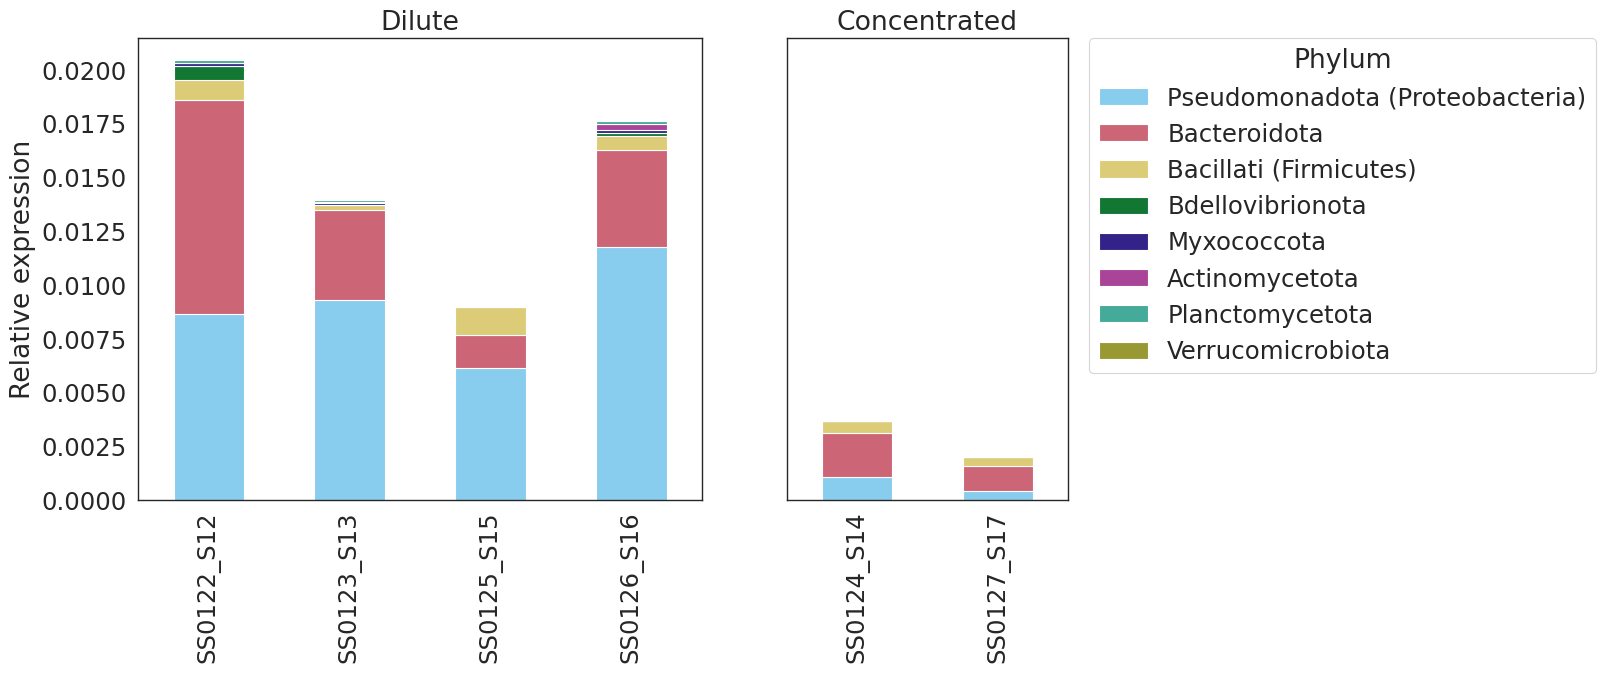

In [20]:
#Plot heterotroph community expression
heterotroph_tpm = phyla_rel_tpm.iloc[2:]
nonslick = heterotroph_tpm[['SS0122_S12','SS0123_S13','SS0125_S15','SS0126_S16']].T
slick = heterotroph_tpm[['SS0124_S14','SS0127_S17']].T
from pypalettes import load_cmap
cmap = load_cmap("Safe").hex
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, sharey=True,figsize=(12, 6),width_ratios=[4,2])
nonslick.plot.bar(stacked=True, ax=ax0,legend=False,color=cmap)
ax0.set_title('Dilute')
ax0.set(xlabel=None, ylabel='Relative expression')
slick.plot.bar(stacked=True, ax=ax1,legend=False,color=cmap)
ax1.set_title('Concentrated')
ax1.set(xlabel=None)
color,label=ax0.get_legend_handles_labels()
fig.legend([ax0, ax1], labels=label,loc="upper right",bbox_to_anchor=(1.35,.9),title='Phylum')
#plt.savefig('output_figures/supp_fig_heterotroph_community_exp.svg',transparent=True,bbox_inches='tight')

/var/tmp/ipykernel_71842/2706302266.py:23: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([ax0, ax1], labels=label,


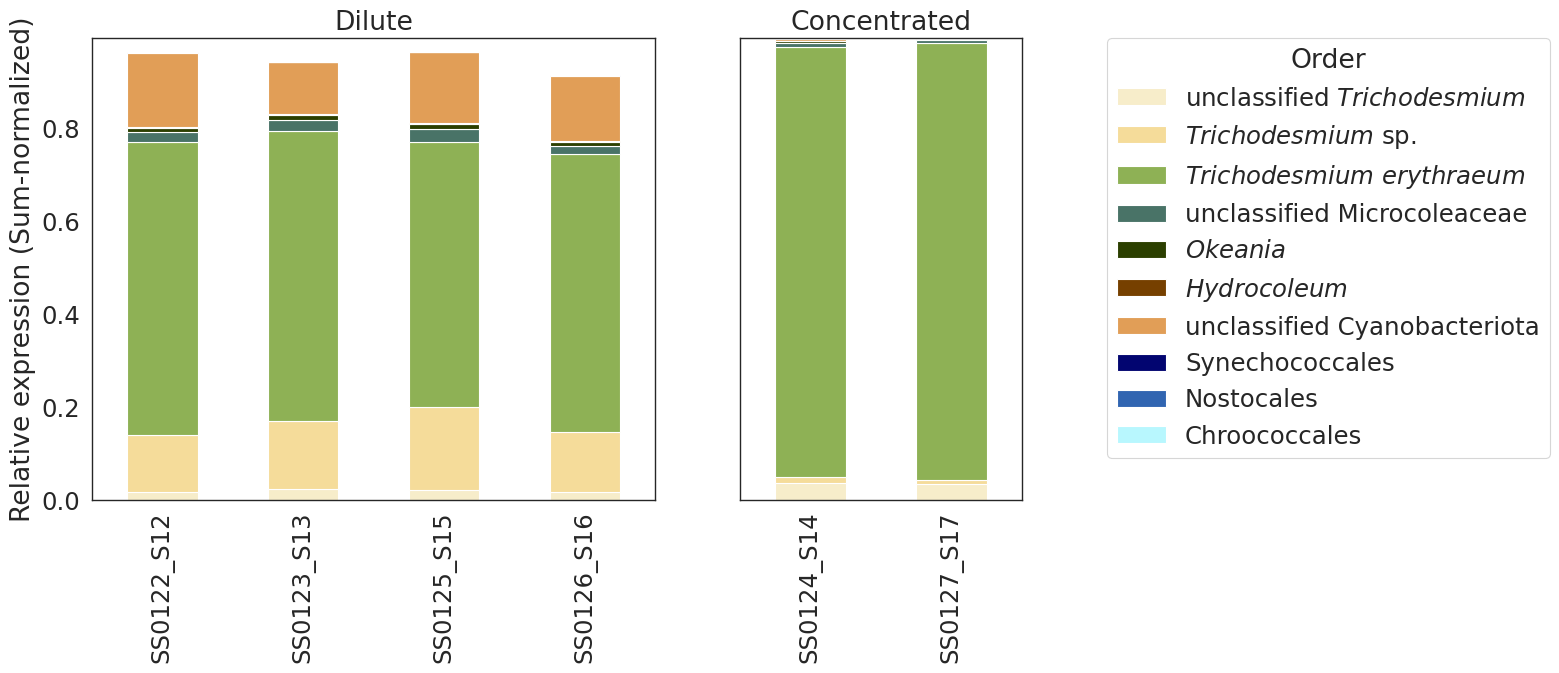

In [21]:
#Plot cyanobacterial community expression

order_tpm = tax_tpm[tax_tpm['phylum'] == 'Cyanobacteriota'].groupby('order')[['SS0127_S17','SS0126_S16', 'SS0124_S14', 'SS0125_S15', 'SS0123_S13', 'SS0122_S12']].sum().drop(['Oscillatoriales'])
#Remove filamentous cyano order and replace with fine-grained info
fil = tax_tpm[tax_tpm['order'] == 'Oscillatoriales'].groupby('genus')[['SS0127_S17','SS0126_S16', 'SS0124_S14', 'SS0125_S15', 'SS0123_S13', 'SS0122_S12']].sum().drop(['Trichodesmium'])
tricho = tax_tpm[tax_tpm['genus'] == 'Trichodesmium'].groupby('species')[['SS0127_S17','SS0126_S16', 'SS0124_S14', 'SS0125_S15', 'SS0123_S13', 'SS0122_S12']].sum()
order_adj = pd.concat([order_tpm,fil,tricho])
order_rel = order_adj/tax_tpm[['SS0127_S17','SS0126_S16', 'SS0124_S14', 'SS0125_S15', 'SS0123_S13', 'SS0122_S12']].sum()
order_rel.rename(index={'Hydrocoleum' : r"$\mathit{Hydrocoleum}$", 'Okeania':r"$\mathit{Okeania}$",'Trichodesmium erythraeum':r"$\mathit{Trichodesmium\ erythraeum}$",
                        'Trichodesmium sp.':r'$\mathit{Trichodesmium}$ sp.','unclassified Trichodesmium':r'unclassified $\mathit{Trichodesmium}$'}, inplace=True)
nonslick = order_rel.iloc[::-1][['SS0122_S12','SS0123_S13','SS0125_S15','SS0126_S16']].T
slick = order_rel.iloc[::-1][['SS0124_S14','SS0127_S17']].T

cmap = load_cmap("okavango").hex
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, sharey=True,figsize=(12, 6),width_ratios=[4,2])
nonslick.plot.bar(stacked=True, ax=ax0,legend=False,color=cmap)
ax0.set_title('Dilute')
ax0.set(xlabel=None, ylabel='Relative expression (Sum-normalized)')
slick.plot.bar(stacked=True, ax=ax1,legend=False,color=cmap)
ax1.set_title('Concentrated')
ax1.set(xlabel=None)
color,label=ax0.get_legend_handles_labels()
fig.legend([ax0, ax1], labels=label,
           loc="upper right",bbox_to_anchor=(1.35,.9),title='Order')
plt.savefig('output_figures/supp_fig_cyano_community_exp.svg',transparent=True,bbox_inches='tight')
#order_rel.to_csv('metaT_files/cyanobacterial_order_relative_expression.csv')

### Plot total expression for NPAC and SPAC slick metaT samples

In [6]:
phage_tpm = phage_tpm.replace(0,np.nan)
present = (162 - phage_tpm.isna().sum())/162
total_tpm = phage_tpm.sum()

In [7]:
npac_summary = pd.DataFrame(index=phage_tpm.columns.values)
npac_summary.loc[:,'frac_genes'] = present
npac_summary.loc[:,'phage_tpm'] = total_tpm
npac_summary.loc[:,'Region'] = 'North Pacific'
npac_summary.loc[:,'sample_type'] = npac_summary.index.map(sample_dict)
npac_summary.loc[:,'tricho_tpm'] = tax_tpm[tax_tpm['genus'] == 'Trichodesmium'][sample_dict.keys()].sum()

/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/packages/anaconda3-2024.10-1/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/packages/anaconda3-2024.10-1/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Pytho

NameError: name 'tax_tpm' is not defined

In [24]:
spac_summary = pd.read_csv('metaT_files/spac_summary.csv',index_col=0)

In [22]:
summary = pd.concat([npac_summary,spac_summary])
summary.loc[:,'rel_tpm'] = summary['phage_tpm']/summary['tricho_tpm']
summary.loc[:,'log_tpm'] = np.log10(summary['phage_tpm'].replace(0,np.nan))

/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/packages/anaconda3-2024.10-1/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/packages/anaconda3-2024.10-1/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Pytho

NameError: name 'npac_summary' is not defined

In [23]:
#summary.to_csv('output_tables/metaT_total.csv')
summary = pd.read_csv('output_tables/metaT_total.csv',index_col=0)

In [24]:
hex_colors2 = load_cmap("qMSOBuWarm").hex
region_palette = {'Indian':hex_colors2[0],'North Pacific':hex_colors2[1],'South Pacific':hex_colors2[4],'North Atlantic':hex_colors2[6],'npsg_og':'#A37903FF'}

In [25]:
# fig, ax = plt.subplots(figsize=(6,6))
# g = sns.barplot(data=summary,x='sample_type',y='log_tpm',hue='Region',order=['Whole seawater','Dilute','Concentrated'],
#                 palette=region_palette)
# g.set_ylabel('$Log_{10}(TPM)$')
# g.set_xticklabels(['Whole \n seawater','Dilute \n colonies','Concentrated \n slick'])
# g.set_xlabel('')

/var/tmp/ipykernel_48940/1837614050.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Whole\n seawater','Concentrated \n slick'],fontsize=14)
/var/tmp/ipykernel_48940/1837614050.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Dilute\n colonies','Concentrated\n slick'],fontsize=14)


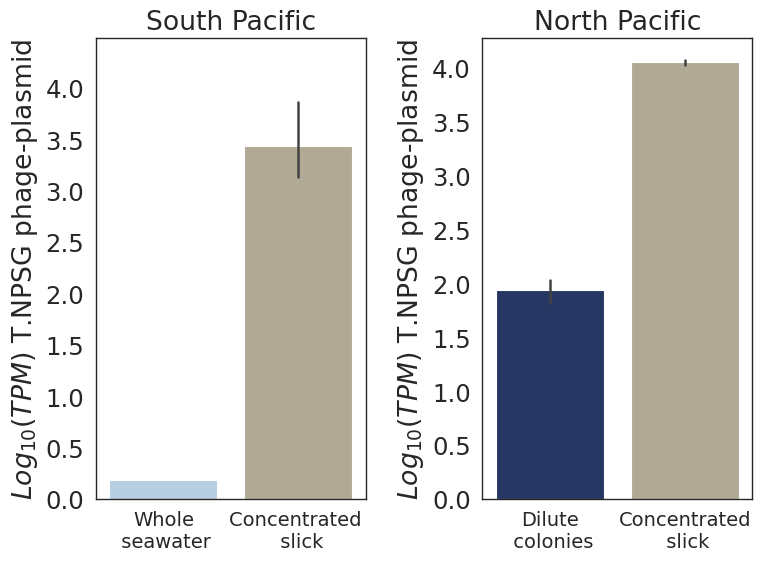

In [31]:
fig, axs = plt.subplots(1,2,figsize=(8,6),layout='tight')
axes = axs.ravel()
sns.barplot(data=summary[summary['Region'] == 'South Pacific'],x='sample_type',y='log_tpm',hue='sample_type',ax=axes[0],order = ['Whole seawater','Concentrated'],
           palette = ['#B5AB8F','#B0CEE8'])
axes[0].set_ylabel('$Log_{10}(TPM)$ T.NPSG phage-plasmid')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Whole\n seawater','Concentrated \n slick'],fontsize=14)
axes[0].set_title('South Pacific')
axes[0].set_ylim(0,4.49)

sns.barplot(data=summary[summary['Region'] == 'North Pacific'],x='sample_type',y='log_tpm',hue='sample_type',ax=axes[1],order = ['Dilute','Concentrated'],
           palette = ['#1B336C','#B5AB8F'])
axes[1].set_ylabel('$Log_{10}(TPM)$ T.NPSG phage-plasmid')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Dilute\n colonies','Concentrated\n slick'],fontsize=14)
axes[1].set_title('North Pacific')
plt.savefig('output_figures/spac_v_npac.svg',transparent=True,bbox_inches='tight')

In [33]:
summary = summary.drop(['SRR2975931','SRR2975929'])
summary.loc[:,'Longitude_plot'] = summary['Longitude'].apply(lambda x: (0 if (x[-1] == 'E') else 360) + (1 if (x[-1] == 'E') else -1) * float(x.split()[0]))
summary.loc[:,'Latitude_plot'] = summary['Latitude'].apply(lambda x: (1 if (x[-1] == 'N') else -1) * float(x.split()[0]))

In [34]:
summary = summary.sort_values(by='sample_type')
summary = summary.rename({'log_tpm':'$Log_{10}(TPM)$','sample_type':'Sample Type'},axis=1)

In [35]:
sample_palette = {'Dilute':'#1B336C','Concentrated':'#B5AB8F','Whole seawater':'#B0CEE8'}

In [36]:
from mpl_toolkits.basemap import Basemap

In [37]:
summary

,frac_genes,phage_tpm,Region,Sample Type,tricho_tpm,rel_tpm,$Log_{10}(TPM)$,Latitude,Longitude,Longitude_plot,Latitude_plot
SS0124_S14,1.000000,10718.767790,North Pacific,Concentrated,3.671002e+06,0.002920,4.030145,24.97 N,158.46 W,201.54,24.97
SS0127_S17,1.000000,11903.139930,North Pacific,Concentrated,4.534592e+06,0.002625,4.075662,26.5 N,158.49 W,201.51,26.50
SRR3924004,0.666667,7417.119277,South Pacific,Concentrated,1.655141e+05,0.044813,3.870235,22.29 S,166.27 E,166.27,-22.29
SRR3924003,0.703704,1361.242515,South Pacific,Concentrated,3.775498e+04,0.036055,3.133936,22.29 S,166.27 E,166.27,-22.29
SRR3924002,0.962963,2000.661883,South Pacific,Concentrated,1.288688e+05,0.015525,3.301174,22.29 S,166.27 E,166.27,-22.29
SS0122_S12,0.413580,110.041218,North Pacific,Dilute,9.689413e+05,0.000114,2.041555,24.70 N,158.69 W,201.31,24.70
SS0126_S16,0.543210,105.053049,North Pacific,Dilute,7.950827e+05,0.000132,2.021409,26.5 N,158.49 W,201.51,26.50
SS0123_S13,0.567901,90.601707,North Pacific,Dilute,9.437212e+05,0.000096,1.957136,24.70 N,158.69 W,201.31,24.70
SS0125_S15,0.524691,57.478523,North Pacific,Dilute,9.932924e+05,0.000058,1.759506,26.5 N,158.49 W,201.51,26.50
SRR2975930,0.006173,1.563551,South Pacific,Whole seawater,4.416905e+03,0.000354,0.194112,22.28 S,166.26 E,166.26,-22.28


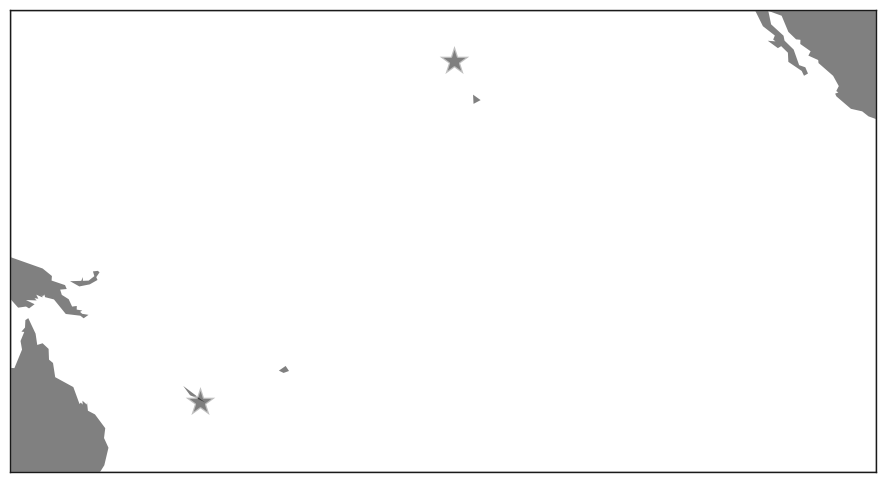

In [51]:
plt.close('all')
fig, ax = plt.subplots(figsize = (12,6))
# llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon
# are the lat/lon values of the lower left and upper right corners
# of the map.
# resolution = 'c' means use crude resolution coastlines.
m = Basemap(projection='cyl',llcrnrlat=-32,urcrnrlat=32,
            llcrnrlon=140,urcrnrlon=260,ax=ax)
m.drawmapboundary(fill_color='white')
#m.drawparallels(np.arange(-60,60,30),labels=[1,0,0,1],color='white',fontsize=14)
#m.drawmeridians(np.arange(150,260,30),labels=[1,0,0,1],color='white',fontsize=14)
m.fillcontinents(color='grey',lake_color='gainsboro')

sns.scatterplot(data=summary.drop_duplicates(subset='Region'),x='Longitude_plot',y='Latitude_plot',ax=ax,s=500,marker='*',color='black',alpha=0.5)
#sns.move_legend(ax, loc="upper left", bbox_to_anchor=(0.01, .99),fontsize=14)
plt.savefig('output_figures/spac_v_npac_map_no_lines.svg',bbox_inches='tight')
plt.show()

/var/tmp/ipykernel_48940/1001122257.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(['Dilute\n colonies','Concentrated\n slick'],fontsize=18)
/var/tmp/ipykernel_48940/1001122257.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(['Whole\n seawater','Concentrated\n slick'],fontsize=18)


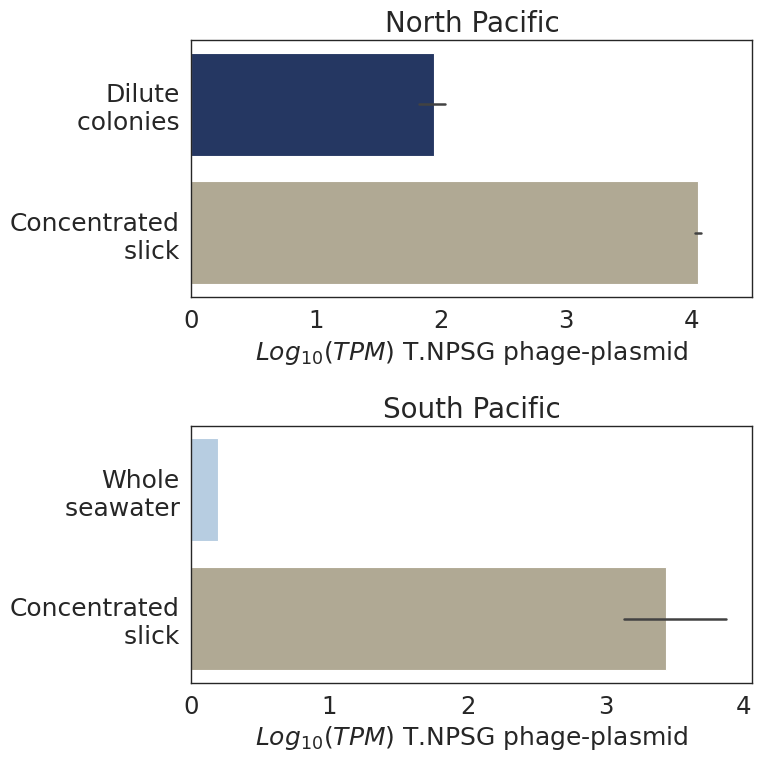

In [59]:
fig, axs = plt.subplots(2,1,figsize=(8,8),layout='tight')
axes = axs.ravel()

sns.barplot(data=summary[summary['Region'] == 'North Pacific'],x='$Log_{10}(TPM)$',y='Sample Type',hue='Sample Type',ax=axes[0],order = ['Dilute','Concentrated'],
           palette = ['#B5AB8F','#1B336C'])
axes[0].set_xlabel('$Log_{10}(TPM)$ T.NPSG phage-plasmid',fontsize=18)
axes[0].set_ylabel('')
axes[0].set_yticklabels(['Dilute\n colonies','Concentrated\n slick'],fontsize=18)
axes[0].set_title('North Pacific',fontsize=20)
axes[0].set_xlim(0,4.49)

sns.barplot(data=summary[summary['Region'] == 'South Pacific'],x='$Log_{10}(TPM)$',y='Sample Type',hue='Sample Type',ax=axes[1],order = ['Whole seawater','Concentrated'],
           palette = ['#B5AB8F','#B0CEE8'])
axes[1].set_xlabel('$Log_{10}(TPM)$ T.NPSG phage-plasmid',fontsize=18)
axes[1].set_ylabel('')
axes[1].set_yticklabels(['Whole\n seawater','Concentrated\n slick'],fontsize=18)
axes[1].set_title('South Pacific',fontsize=20)
plt.savefig('output_figures/spac_v_npac.svg',transparent=True,bbox_inches='tight')

## Differential expression of T. erythraeum genes between colonies and slick

In [23]:
#Get all contigs whose LCA is T. erythraeum
t_ery = gtdb_tax[gtdb_tax['LCA'] == 'Trichodesmium erythraeum']['contig'].values

In [24]:
#Get coordinates of genes in T. erythraeum genome
gene_info=pd.read_csv('metaT_files/hybrid_assembly_prots.bed',sep='\t',names = ['gene','contig','start','end'])
gene_info

,gene,contig,start,end
0,NODE_1_length_148236_cov_916.668891_1,NODE_1_length_148236_cov_916.668891,76,1020
1,NODE_1_length_148236_cov_916.668891_2,NODE_1_length_148236_cov_916.668891,1692,2549
2,NODE_1_length_148236_cov_916.668891_3,NODE_1_length_148236_cov_916.668891,2876,3274
3,NODE_1_length_148236_cov_916.668891_4,NODE_1_length_148236_cov_916.668891,3694,4590
4,NODE_1_length_148236_cov_916.668891_5,NODE_1_length_148236_cov_916.668891,4992,6488
...,...,...,...,...
135316,NODE_167508_length_60_cov_4.200000_1,NODE_167508_length_60_cov_4.200000,1,60
135317,NODE_167721_length_60_cov_3.000000_1,NODE_167721_length_60_cov_3.000000,1,60
135318,NODE_167724_length_60_cov_3.000000_1,NODE_167724_length_60_cov_3.000000,1,60
135319,NODE_167728_length_60_cov_3.000000_1,NODE_167728_length_60_cov_3.000000,1,60


In [20]:
to_cat_tpm = []
to_cat_counts = []
for file in glob.glob('metaT_files/*_hybrid_assembly_cds_cov.tab'):
    sample_id = file.rsplit('/',maxsplit=1)[1].split('_')[0]+'_'+file.rsplit('/',maxsplit=1)[1].split('_')[1]
    infile = pd.read_csv(file,sep='\t',header=None,names=['contig','start','end','depth','reads'])
    merged = pd.merge(gene_info,infile,on=['contig','start','end'],how='inner')
    merged = merged[merged['contig'].isin(t_ery)]
    merged.loc[:,'length'] = merged['end'].astype(int) - merged['start']
    merged.loc[:,'rpk'] = merged['reads']/(merged['length']/1000)
    t_ery_scale = infile[infile['contig'].isin(t_ery)]
    pm_scale = (t_ery_scale['reads']/(t_ery_scale['end']/1000)).sum()/1000000
    merged.loc[:,'tpm'] = (merged['rpk']/pm_scale)
    merged = merged.set_index('gene')
    tpms = merged['tpm']
    tpms.name = sample_id
    counts = merged['reads']
    counts.name = sample_id
    to_cat_tpm.append(tpms)
    to_cat_counts.append(counts)

tery_tpm = pd.concat(to_cat_tpm,axis=1).reset_index()
tery_tpm.loc[:,'contig'] = tery_tpm['gene'].str.rsplit('_',n=1,expand=True)[0]
tery_tpm = tery_tpm[tery_tpm['contig'].isin(t_ery)].drop(['contig'],axis=1).set_index('gene')
tery_tpm =  tery_tpm[tery_tpm.sum(axis=1) > 0]
tery_counts = pd.concat(to_cat_counts,axis=1).reset_index()
tery_counts.loc[:,'contig'] = tery_counts['gene'].str.rsplit('_',n=1,expand=True)[0]
tery_counts = tery_counts[tery_counts['contig'].isin(t_ery)].drop(['contig'],axis=1).set_index('gene')
tery_counts =  tery_counts[tery_counts.sum(axis=1) > 0]


In [21]:
#tery_counts.to_csv('metaT_files/tery_raw_gene_counts.csv')
#tery_tpm.to_csv('metaT_files/tery_tpm.csv')

### tery_raw_gene_counts.csv used as input for deseq.R

In [175]:
#read in deseq2 results
deseqRes = pd.read_csv('metaT_files/t_e_deseq_resdf.csv',index_col=0)
deseqRes['significant'] = deseqRes['significant'].fillna('Non-significant')
deseqRes.loc[:,'-log10p'] = -1*np.log10(deseqRes['padj'])
deseqRes.loc[:,'log2mean'] = np.log2(deseqRes['baseMean'])

In [176]:
tery_tpm = pd.read_csv('metaT_files/tery_tpm.csv',index_col=0)

In [177]:
#read in functional annotations
#Kofam annotations of assembly:
kofam = pd.read_csv('/ocean/projects/ees230009p/shared/slick_bins/kofam_long_read_assembly.txt',sep='\t',skiprows=[0,1],usecols=[1,2,3,4,5,6],names=['gene name',	'KO',	'thrshld',	'score',	'E-value',	'KO definition'],index_col=None)
#Get best hits only
kofam = kofam.sort_values(by='E-value',ascending=True).drop_duplicates(keep='first',subset='gene name')
kofam = kofam[kofam['E-value'] < 10e-10]
kofam.loc[:,'contig'] = kofam['gene name'].str.rsplit('_',n=1,expand=True)[0]
#emapper annotations of assembly
emapper = pd.read_csv('/ocean/projects/ees240006p/agomez3/tricho_virus/tricho_slick_assembly/eggnog_out/emapper_annotations.emapper.annotations',sep='\t',skiprows=[0, 1,2,3])
emapper_tery = emapper[emapper['#query'].isin(tery_tpm.index.values)]

In [178]:
tery_annot_kofam = kofam[kofam['gene name'].isin(deseqRes.index.values)].set_index('gene name')
tery_annot = emapper_tery[emapper_tery['#query'].isin(deseqRes.index.values)].set_index('#query')
de_tery = pd.concat([tery_annot_kofam,deseqRes,tery_annot],axis=1)

In [179]:
write = de_tery[['baseMean', 'log2FoldChange','padj','seed_ortholog', 'evalue', 'score', 'eggNOG_OGs', 'max_annot_lvl',
       'COG_category', 'Description', 'Preferred_name', 'GOs', 'EC', 'KEGG_ko','KO definition',
       'KEGG_Pathway','significant']]
write[(write['significant'] == 'Significant') & (~write['COG_category'].isna())].sort_values(by='log2FoldChange').to_csv('metaT_files/all_sig_tery.csv')

In [180]:
deseqRes_annot = pd.merge(left=deseqRes,right=tery_annot,left_index=True,right_index=True,how='left')
deseqRes_annot.loc[:,'COG_category'] = deseqRes_annot['COG_category'].str[0].fillna('-')
deseqRes_annot = deseqRes_annot[deseqRes_annot['log2mean'] > 0.1]
#remove outlier
deseqRes_annot = deseqRes_annot[deseqRes_annot['log2FoldChange'] > -25]

In [181]:
cmap = load_cmap("golduck")
cmap1 = load_cmap("golduck").hex
cmap = load_cmap("spinarak")
cmap2 = cmap.hex

In [182]:
COG_function_dict = {'J':'Translation, ribosomal structure and biogenesis', 'A': 'RNA processing and modification', 'K': 'Transcription','L':'Replication, recombination and repair','B': 'Chromatin structure and dynamics',
                     'D': 'Cell cycle control, cell division, chromosome partitioning','V':'Defense mechanisms','T':'Signal transduction','M':'Cell wall/membrane/envelope biogenesis','N': 'Motility', 'U': 'Intracellular trafficking, secretion, and vesicular transport','O':'Posttranslational modification, protein turnover, chaperones',
                     'C': 'Energy production and conversion','G': 'Carbohydrate transport and metabolism', 'E':'Amino acid transport and metabolism','F':'Nucleotide transport and metabolism','H':'Coenzyme transport and metabolism', 'I':'Lipid transport and metabolism','P':'Inorganic ion transport and metabolism','Q':'Secondary metabolites biosynthesis, transport and catabolism',
                     'S':'Uncategorized','-':'Uncategorized'}
COG_color_dict = {'J':cmap1[0], 'A': 'grey', 'K': cmap1[2],'L':cmap1[3],'B': 'grey',
                     'D': cmap2[0],'T':cmap2[2],'M':cmap2[4],'N': cmap2[5], 'U': cmap1[5],'O':cmap2[6],
                      'V':'#11C2B5FF',
                     'C': cmap1[9],'G': cmap1[11], 'E':cmap1[12],'F':cmap2[9],'H':cmap2[12], 'I':cmap2[13],'P':'#A82838FF','Q':'#782028FF',
                     'S':'grey','-':'grey'}
COG_label_dict = {'J':'Information storage & processing', 'A': 'Information storage & processing', 'K': 'Information storage & processing','L':'Information storage & processing','B': 'Information storage & processing',
                     'D': 'Cellular processes & signaling','V':'Defense mechanisms','T':'Cellular processes & signaling','M':'Cellular processes & signaling','N': 'Cellular processes & signaling', 'U': 'Cellular processes & signaling','O':'Cellular processes & signaling',
                     'C': 'Metabolism','G': 'Metabolism', 'E':'Metabolism','F':'Metabolism','H':'Metabolism', 'I':'Metabolism','P':'Metabolism','Q':'Metabolism',
                     'S':'Uncategorized','-':'Uncategorized'}

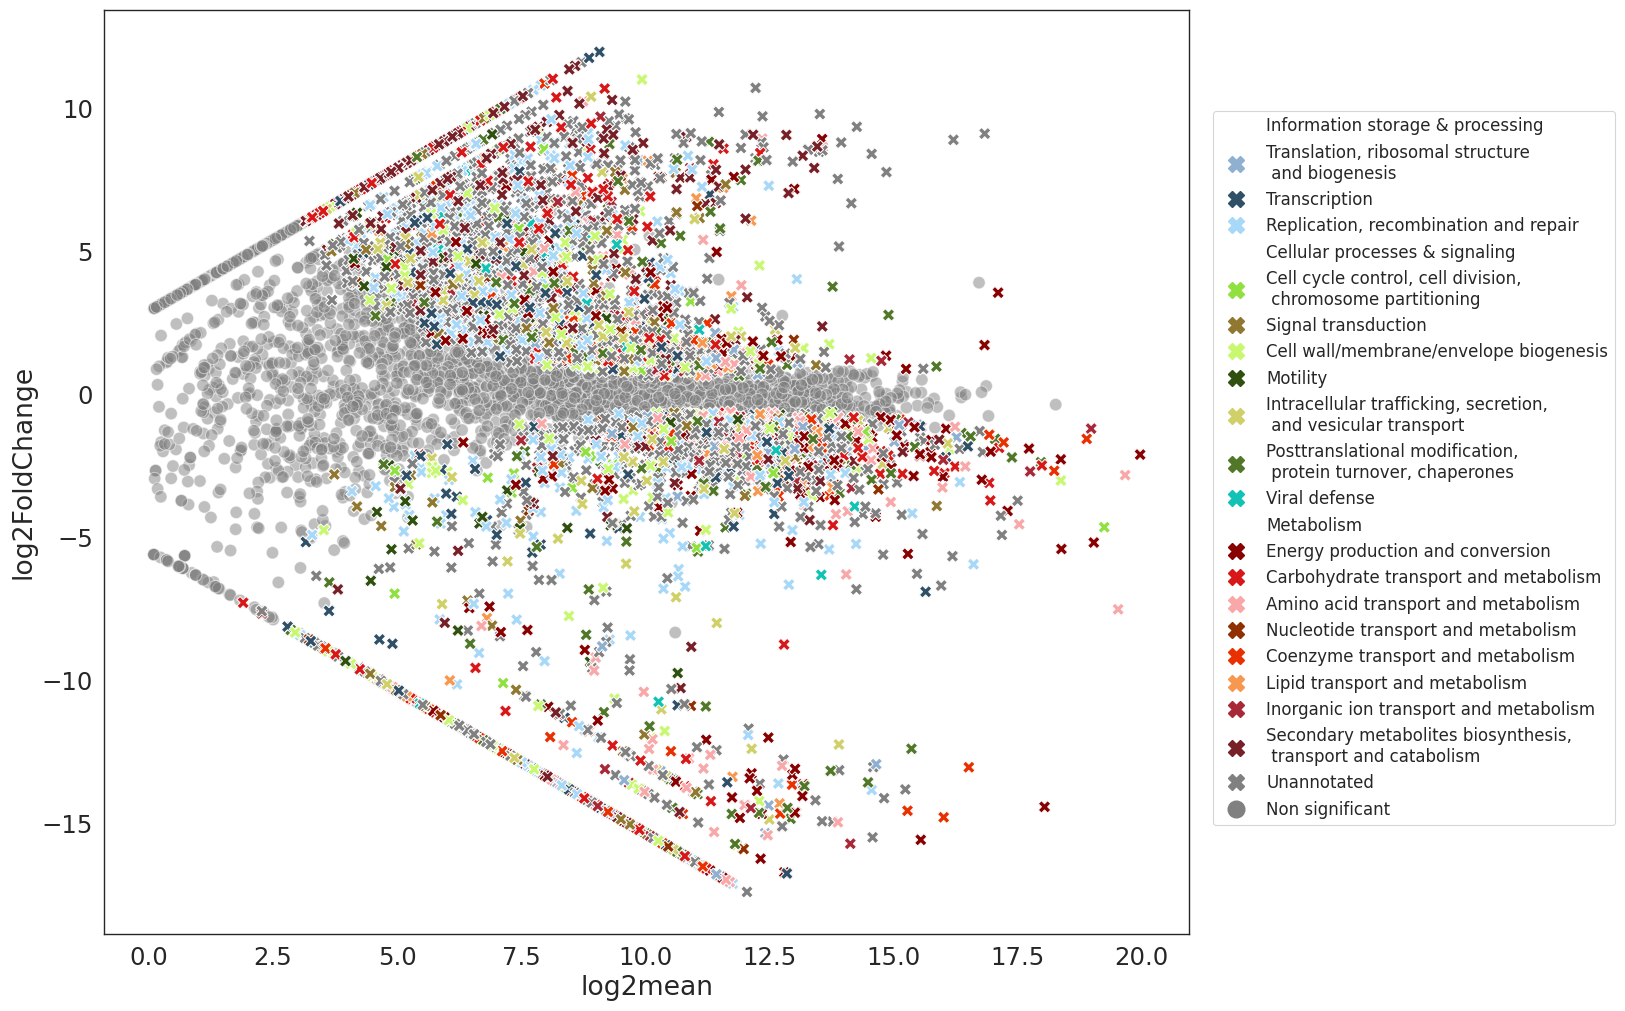

In [13]:
fig,axs = plt.subplots(figsize=(14,12))
g = sns.scatterplot(data = deseqRes_annot, x = 'log2mean',y='log2FoldChange',style='significant',color='grey',alpha=0.5,legend=False,s=80)
g = sns.scatterplot(data = deseqRes_annot[deseqRes_annot['significant'] == 'Significant'], x = 'log2mean',y='log2FoldChange',marker='X',s=80,hue='COG_category',palette=COG_color_dict,legend=False)
info = mlines.Line2D([], [], marker='None', linestyle='None',label='Information storage & processing')
set1 = mlines.Line2D([], [], color=cmap1[0], marker='X', linestyle='None',markersize=12, label='Translation, ribosomal structure \n and biogenesis')
set2 = mlines.Line2D([], [], color=cmap1[2], marker='X', linestyle='None', markersize=12, label='Transcription')
set3 = mlines.Line2D([], [], color=cmap1[3], marker='X', linestyle='None',markersize=12, label='Replication, recombination and repair')
process = mlines.Line2D([], [], marker='None', linestyle='None',label='Cellular processes & signaling')
p1 = mlines.Line2D([], [], color=cmap2[0], marker='X', linestyle='None',markersize=12, label='Cell cycle control, cell division, \n chromosome partitioning')
p2 = mlines.Line2D([], [], color=cmap2[2], marker='X', linestyle='None', markersize=12, label='Signal transduction')
p3 = mlines.Line2D([], [], color=cmap2[4], marker='X', linestyle='None',markersize=12, label='Cell wall/membrane/envelope biogenesis')
p4 = mlines.Line2D([], [], color=cmap2[5], marker='X', linestyle='None',markersize=12, label='Motility')
p5 = mlines.Line2D([], [], color=cmap1[5], marker='X', linestyle='None',markersize=12, label='Intracellular trafficking, secretion, \n and vesicular transport')
p6 = mlines.Line2D([], [], color=cmap2[6], marker='X', linestyle='None',markersize=12, label='Posttranslational modification, \n protein turnover, chaperones')
met = mlines.Line2D([], [], marker='None', linestyle='None',label='Metabolism')
m1 = mlines.Line2D([], [], color=cmap1[9], marker='X', linestyle='None', markersize=12, label='Energy production and conversion')
m2 = mlines.Line2D([], [], color=cmap1[11], marker='X', linestyle='None', markersize=12, label='Carbohydrate transport and metabolism')
m3 = mlines.Line2D([], [], color=cmap1[12], marker='X', linestyle='None', markersize=12, label='Amino acid transport and metabolism')
m4 = mlines.Line2D([], [], color=cmap2[9], marker='X', linestyle='None', markersize=12, label='Nucleotide transport and metabolism')
m5 = mlines.Line2D([], [], color=cmap2[12], marker='X', linestyle='None', markersize=12, label='Coenzyme transport and metabolism')
m6 = mlines.Line2D([], [], color=cmap2[13], marker='X', linestyle='None', markersize=12, label='Lipid transport and metabolism')
m7 = mlines.Line2D([], [], color='#A82838FF', marker='X', linestyle='None', markersize=12, label='Inorganic ion transport and metabolism')
m8 = mlines.Line2D([], [], color='#782028FF', marker='X', linestyle='None', markersize=12, label='Secondary metabolites biosynthesis, \n transport and catabolism')
defense = mlines.Line2D([], [], color='#11C2B5FF', marker='X', linestyle='None', markersize=12, label='Viral defense')
undef = mlines.Line2D([], [], color='grey', marker='X', linestyle='None', markersize=12, label='Unannotated')
nonsig = mlines.Line2D([], [], color='grey', marker='o', linestyle='None', markersize=12, label='Non significant')
plt.legend(handles=[info,set1,set2,set3,process,p1,p2,p3,p4,p5,p6,defense,met,m1,m2,m3,m4,m5,m6,m7,m8,undef,nonsig],bbox_to_anchor=(1.4,.9),loc='upper right', fontsize=12)
#plt.savefig('output_figures/supp_fig_tery_metaT.png',bbox_inches='tight')

In [14]:
tery_annot_kofam[tery_annot_kofam['KO'].str.contains('K22684',na=False)]

,KO,thrshld,score,E-value,KO definition,contig
gene name,,,,,,
NODE_230_length_17201_cov_415.618745_4,K22684,80.93,117.6,7.200000e-33,metacaspase-1 [EC:3.4.22.-],NODE_230_length_17201_cov_415.618745
NODE_2907_length_928_cov_529.840779_1,K22684,80.93,81.9,4.600000e-22,metacaspase-1 [EC:3.4.22.-],NODE_2907_length_928_cov_529.840779
NODE_101_length_34191_cov_500.193198_11,K22684,80.93,69.5,2.600000e-18,metacaspase-1 [EC:3.4.22.-],NODE_101_length_34191_cov_500.193198
NODE_211_length_19130_cov_465.869934_1,K22684,80.93,66.3,2.500000e-17,metacaspase-1 [EC:3.4.22.-],NODE_211_length_19130_cov_465.869934
NODE_6328_length_571_cov_772.957364_1,K22684,80.93,59.3,3.300000e-15,metacaspase-1 [EC:3.4.22.-],NODE_6328_length_571_cov_772.957364
NODE_495_length_7042_cov_474.475311_4,K22684,80.93,53.6,1.800000e-13,metacaspase-1 [EC:3.4.22.-],NODE_495_length_7042_cov_474.475311
NODE_1999_length_1247_cov_103.607383_1,K22684,80.93,49.5,3.000000e-12,metacaspase-1 [EC:3.4.22.-],NODE_1999_length_1247_cov_103.607383


In [183]:
metacaspase = tery_annot_kofam[tery_annot_kofam['KO definition'].str.contains('caspase',na=False)].index.values
deseqRes_annot.loc[metacaspase]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,-log10p,log2mean,seed_ortholog,...,KEGG_ko,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rclass,BRITE,KEGG_TC,CAZy,BiGG_Reaction,PFAMs
NODE_230_length_17201_cov_415.618745_4,1385.741670,0.914492,0.259822,3.519690,4.320508e-04,1.079004e-03,Significant,2.966977,10.436443,203124.Tery_2624,...,-,-,-,-,-,-,-,-,-,"DUF4384,Peptidase_C14"
NODE_2907_length_928_cov_529.840779_1,1005.338126,0.584419,0.508627,1.149011,2.505513e-01,3.274212e-01,Non-significant,0.484893,9.973465,203124.Tery_1841,...,-,-,-,-,-,-,-,-,-,"HEAT_2,HEAT_PBS,Metallophos,NACHT,NB-ARC,Pepti..."
NODE_101_length_34191_cov_500.193198_11,252.833117,7.453707,0.933737,7.982659,1.432143e-15,1.223608e-14,Significant,13.912358,7.982042,203124.Tery_2058,...,-,-,-,-,-,-,-,-,-,Peptidase_C14
NODE_211_length_19130_cov_465.869934_1,1119.967947,-0.238341,0.460252,-0.517848,6.045644e-01,6.668638e-01,Non-significant,0.175963,10.129242,203124.Tery_2689,...,-,-,-,-,-,-,-,-,-,"FGE-sulfatase,Peptidase_C14"
NODE_6328_length_571_cov_772.957364_1,323.407871,-0.070067,0.503131,-0.139262,8.892431e-01,9.124117e-01,Non-significant,0.039809,8.337211,203124.Tery_2077,...,-,-,-,-,-,-,-,-,-,"FGE-sulfatase,Peptidase_C14"
NODE_495_length_7042_cov_474.475311_4,583.656960,0.817974,0.381495,2.144130,3.202246e-02,5.492994e-02,Non-significant,1.260191,9.188977,203124.Tery_2760,...,-,-,-,-,-,-,-,-,-,Peptidase_C14
NODE_1999_length_1247_cov_103.607383_1,567.932168,-6.770629,0.413182,-16.386552,2.385992e-60,2.463682e-58,Significant,57.608415,9.149575,203124.Tery_2077,...,-,-,-,-,-,-,-,-,-,"FGE-sulfatase,Peptidase_C14"


In [184]:
deseqRes_annot[(deseqRes_annot['PFAMs'].str.contains('FGE-sulfatase',na=False)) & (deseqRes_annot['significant'] == 'Significant')]['seed_ortholog'].value_counts()

seed_ortholog
203124.Tery_2136             9
203124.Tery_4351             9
203124.Tery_0463             8
203124.Tery_2077             6
203124.Tery_4304             6
203124.Tery_2228             5
203124.Tery_2689             4
203124.Tery_2415             4
203124.Tery_0247             3
203124.Tery_2006             3
203124.Tery_1036             3
203124.Tery_1568             3
203124.Tery_0462             3
203124.Tery_2585             2
203124.Tery_0461             2
203124.Tery_2071             2
203124.Tery_3524             2
203124.Tery_1239             2
203124.Tery_2061             2
203124.Tery_4394             1
65093.PCC7418_2258           1
203124.Tery_2829             1
99598.Cal7507_5672           1
1173264.KI913949_gene1338    1
391612.CY0110_22572          1
118173.KB235914_gene335      1
203124.Tery_2069             1
65393.PCC7424_3565           1
203124.Tery_3529             1
203124.Tery_2963             1
203124.Tery_4550             1
203124.Tery_3719         

In [185]:
deseqRes_annot[deseqRes_annot['seed_ortholog'] == '203124.Tery_2559']

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,-log10p,log2mean,seed_ortholog,...,KEGG_ko,KEGG_Pathway,KEGG_Module,KEGG_Reaction,KEGG_rclass,BRITE,KEGG_TC,CAZy,BiGG_Reaction,PFAMs
NODE_12_length_84605_cov_817.129698_37,161035.524282,-4.081896,0.372824,-10.948592,6.748820e-28,1.937026e-26,Significant,25.712865,17.297019,203124.Tery_2559,...,ko:K03839,-,-,-,-,ko00000,-,-,-,Flavodoxin_1


## Differential expression of specific functions in T. erythraeum

In [186]:
#Known KOs of Fe, P, and nucleotide stress response
pstress_ko = ['K06163','K07093','K07093','K02040','K01406','K01406','K01126','K06118']
nucl_met_ko = ['K13483','K01485','K09903','K00764','K03787','K01939','K01955','K00945','K13799','K03787','K01465','K01465','K03787','K02428','K00948','K01591','K00759','K01524']
fe_stress_ko = ['K09772','K03798','K03531','K03798','K03798','K03711','K03798','K02638','K08906','K03711','K01623','K02313','K03839','K00485','K02012','K04758','K04759','K03839','K02650','K02705','K21480','K04047','K03594']
metac_ko = ['K22684']
p_stress_genes = list(tery_annot_kofam[tery_annot_kofam['KO'].isin(pstress_ko)].index.values)
nucl_met_genes = list(tery_annot_kofam[tery_annot_kofam['KO'].isin(nucl_met_ko)].index.values)
fe_stress_genes = list(tery_annot_kofam[tery_annot_kofam['KO'].isin(fe_stress_ko)].index.values)
metacaspase = list(tery_annot_kofam[tery_annot_kofam['KO'].isin(metac_ko)].index.values)

In [187]:
metacaspase

['NODE_230_length_17201_cov_415.618745_4',
 'NODE_2907_length_928_cov_529.840779_1',
 'NODE_101_length_34191_cov_500.193198_11',
 'NODE_211_length_19130_cov_465.869934_1',
 'NODE_6328_length_571_cov_772.957364_1',
 'NODE_495_length_7042_cov_474.475311_4',
 'NODE_1999_length_1247_cov_103.607383_1']

In [188]:
#genes encoding gas vesicle proteins
gv = list(de_tery[(de_tery['KO definition'].str.contains('gas vesicle',na=False)) | (de_tery['Description'].str.contains('gas vesicle',na=False))].sort_values(by='E-value').index.values)

In [189]:
len(nucl_met_genes)

15

In [198]:
gene_list = {'P stress': p_stress_genes, 'Nucleotide metabolism': nucl_met_genes,'Fe stress':fe_stress_genes,'Gas vesicles':gv, 
            'Metacaspase' : metacaspase}
to_cat = []
to_cat_df = []
for group in gene_list.keys():
    genes = gene_list[group]
    write_subset = write.loc[genes]
    write_subset.loc[:,'Stress Category'] = group
    to_cat_df.append(write_subset)
    tpm_stacked = tery_tpm.loc[genes].stack().reset_index()
    tpm_stacked.columns = ['cds_id','sample','tpm']
    tpm_stacked['tpm'] = tpm_stacked['tpm'].astype('float')
    tpm_stacked.loc[:,'log_tpm'] = np.log10(tpm_stacked['tpm'])
    tpm_stacked.loc[:,'Sample Type'] = tpm_stacked['sample'].map(sample_dict)
    tpm_stacked.loc[:,'category'] = group
    to_cat.append(tpm_stacked)
all_groups = pd.concat(to_cat)
all_groups = all_groups.reset_index()

/jet/home/agomez3/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/jet/home/agomez3/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/jet/home/agomez3/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/jet/home/agomez3/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [199]:
#pd.concat(to_cat_df).to_csv('output_tables/supp_table_fig2b.csv')

In [200]:
#tery_tpm.loc[pd.concat(to_cat_df).index.values].to_csv('output_tables/supp_table_fig2b_tpm.csv')

<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
/var/tmp/ipykernel_71842/1667384962.py:5: SyntaxWarning: invalid escape sequence '\i'
  g.set(title='$\it{Trichodesmium}$'+' '+ '$\it{erythraeum}$'+' gene expression - NPSG')
/var/tmp/ipykernel_71842/1667384962.py:5: SyntaxWarning: invalid escape sequence '\i'
  g.set(title='$\it{Trichodesmium}$'+' '+ '$\it{erythraeum}$'+' gene expression - NPSG')


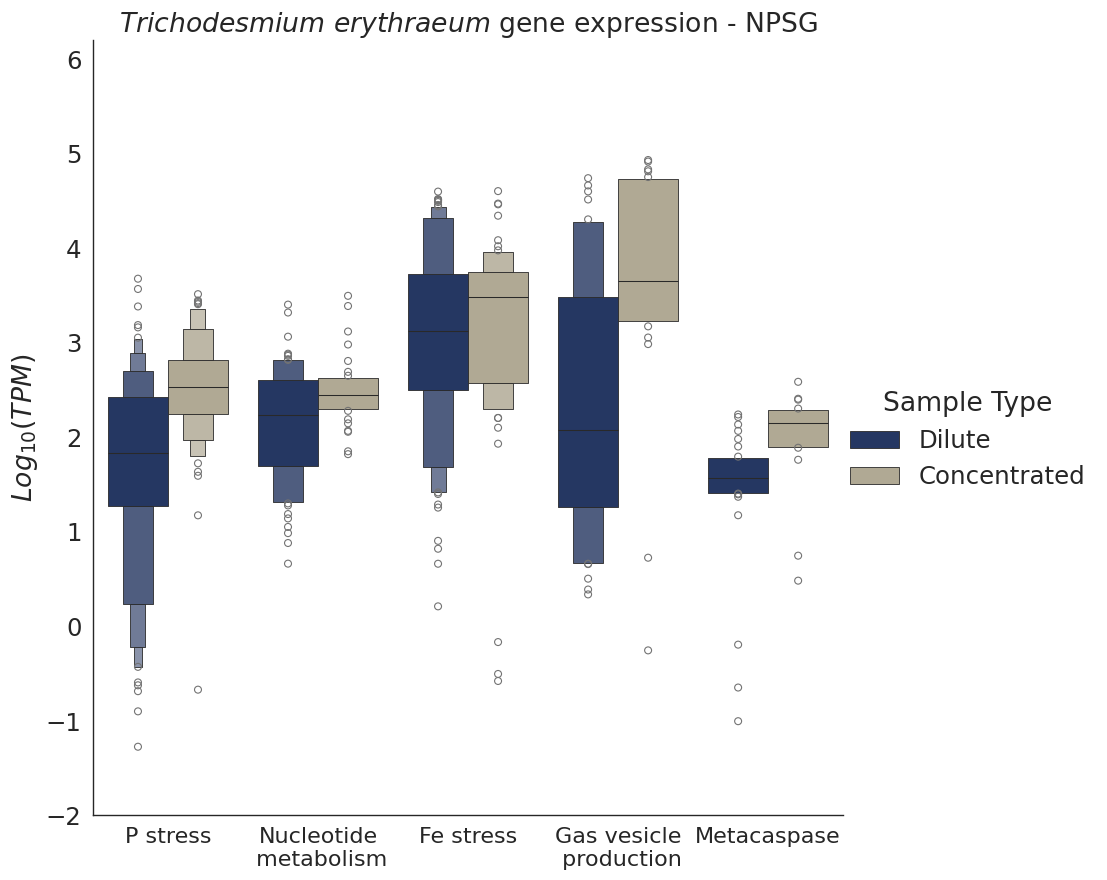

In [219]:
g = sns.catplot(data=all_groups, hue='Sample Type', y='log_tpm',x='category', palette = ['#1B336C','#B5AB8F'],kind='boxen',height=9, aspect=1,hue_order=['Dilute','Concentrated'])
g.set_axis_labels('Functional Category','$Log_{10}(TPM)$')
g.set_xticklabels(["P stress", "Nucleotide\n metabolism", "Fe stress", 'Gas vesicle\n production','Metacaspase'],fontsize=16)
g.set(ylim=(-2, 6.2))
g.set(title='$\it{Trichodesmium}$'+' '+ '$\it{erythraeum}$'+' gene expression - NPSG')
g.set(xlabel='')
plt.savefig('output_figures/fig2b_tery_stress_comp.svg',transparent=True,bbox_inches='tight')

In [64]:
#KS test between Picked colonies and slick for 4 functional categories
for group in all_groups['category'].unique():
    non_slick = all_groups[(all_groups['source'] == 'Dilute') & (all_groups['category'] == group)]['tpm']
    slick = all_groups[(all_groups['source'] == 'Concentrated') & (all_groups['category'] == group)]['tpm']
    print(group,stats.kstest(slick,non_slick))

P stress KstestResult(statistic=0.4418604651162791, pvalue=1.6690070431397923e-10, statistic_location=105.15174373373664, statistic_sign=-1)
Nucleotide metabolism KstestResult(statistic=0.3333333333333333, pvalue=0.02110217477875078, statistic_location=90.64347873264911, statistic_sign=-1)
Fe stress KstestResult(statistic=0.13333333333333333, pvalue=0.46455199338580366, statistic_location=0.6791451379857291, statistic_sign=1)
Gas vesicles KstestResult(statistic=0.4722222222222222, pvalue=0.007653810932745209, statistic_location=822.7579204618297, statistic_sign=-1)
Metacaspase KstestResult(statistic=0.5714285714285714, pvalue=0.003197529237797999, statistic_location=56.36041193848612, statistic_sign=-1)
